In [2]:
import pandas as pd
import matplotlib.pyplot as plt # visualizing data
import seaborn as sns

In [3]:
df = pd.read_csv("VNL2023.csv" )

In [5]:
df.shape

(131, 10)

In [6]:
df.info

<bound method DataFrame.info of                           Player    Country  Age  Attack  Block  Serve   Set  \
0                  Ichikawa Yuki      Japan   28   15.80   1.13   1.40  0.07   
1                    Romano Yuri      Italy   26   12.33   1.07   1.47  0.00   
2               Abdel-Aziz Nimir  Nederland   31   15.33   0.67   2.08  0.00   
3            Herrera Jaime Jesus       Cuba   28   15.00   0.92   1.75  0.00   
4                  Takahashi Ran      Japan   22   11.53   0.67   1.00  0.07   
..                           ...        ...  ...     ...    ...    ...   ...   
126               Graven Leonard    Germany   19    0.00   0.00   0.00  0.00   
127                 Balaso Fabio      Italy   28    0.00   0.00   0.00  0.00   
128      Nacsimento Maique Reis      Brazil   26    0.00   0.00   0.00  0.00   
129  Garcia Alvarez Yonder Roman       Cuba   30    0.00   0.00   0.00  0.00   
130              Salparov Teodor   Bulgaria   41    0.00   0.00   0.00  0.00   

       

In [ ]:
# Here we will check if our database have null value or not

df.isna().sum()

Player      0
Country     0
Age         0
Attack      0
Block       0
Serve       0
Set         0
Dig         0
Receive     0
Position    0
dtype: int64

In [10]:
# Here we will check if we have any duplicat value or not

df.duplicated().sum()

0

In [ ]:
# On this part we have created a correlation between the columns of our dataBase

numeric_corr = df.select_dtypes(include=["int","float"]).columns
corr_martrix = df[numeric_corr].corr()
print(corr_martrix)

              Age    Attack     Block     Serve       Set       Dig   Receive
Age      1.000000 -0.177849 -0.101040 -0.108367  0.177757  0.167141 -0.011067
Attack  -0.177849  1.000000  0.338412  0.768859 -0.430805 -0.098999  0.169892
Block   -0.101040  0.338412  1.000000  0.335954 -0.132019 -0.348347 -0.265206
Serve   -0.108367  0.768859  0.335954  1.000000 -0.154815 -0.052501  0.039642
Set      0.177757 -0.430805 -0.132019 -0.154815  1.000000  0.131659 -0.305869
Dig      0.167141 -0.098999 -0.348347 -0.052501  0.131659  1.000000  0.624733
Receive -0.011067  0.169892 -0.265206  0.039642 -0.305869  0.624733  1.000000


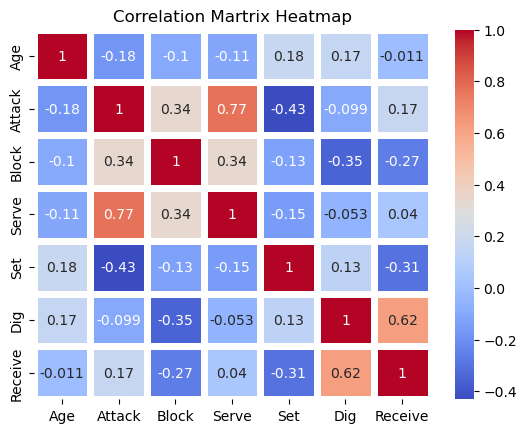

In [12]:
# We will show her the heat map of our between the columns

sns.heatmap(corr_martrix, annot=True, cmap = "coolwarm", linewidths = 5)
plt.title("Correlation Martrix Heatmap")
plt.show()

In [15]:
position_counts = df["Position"].value_counts()
position_counts.index

Index(['OH', 'MB', 'OP', 'S', 'L'], dtype='object', name='Position')

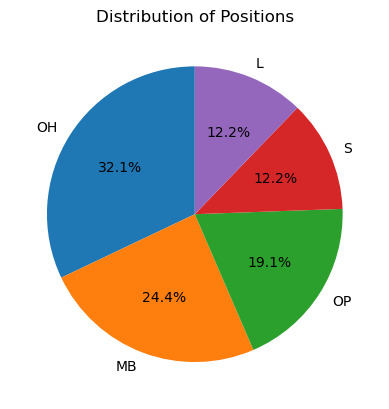

In [14]:
plt.pie(position_counts, labels= position_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribution of Positions")
plt.show()

In [17]:
avg_attack_by_country = df.groupby("Country")["Attack"].mean()
avg_attack_by_country.sort_values(ascending=False)

Country
France       6.670000
Japan        6.595000
Cuba         6.344286
Serbia       5.998750
Italy        5.965000
Slovenia     5.961250
Argentina    5.925000
Nederland    5.880000
Poland       5.807000
Canada       5.405714
Bulgaria     5.282500
Brazil       5.250000
China        5.093750
Germany      4.833750
Iran         4.707778
USA          4.600000
Name: Attack, dtype: float64

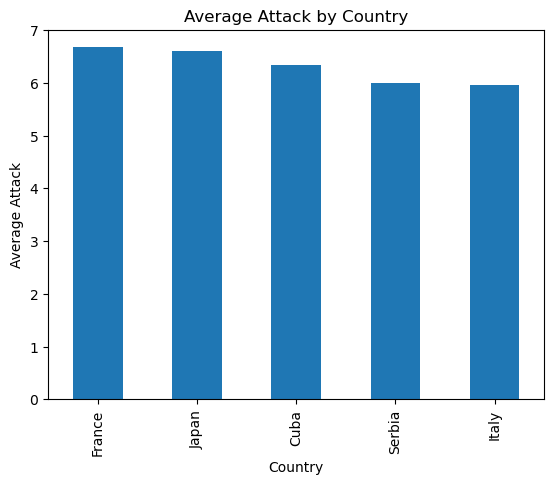

In [19]:
avg_attack_by_country.sort_values(ascending=False).head(5).plot(kind= "bar")
plt.title("Average Attack by Country")
plt.xlabel("Country")
plt.ylabel("Average Attack")
plt.show()

In [20]:
avg_serve_by_age = df.groupby("Age")["Serve"].mean()
avg_serve_by_age.sort_values(ascending=False)

Age
31    0.910000
20    0.880000
21    0.770000
26    0.681053
28    0.667273
35    0.666667
27    0.662500
36    0.660000
24    0.640667
22    0.534286
23    0.526667
29    0.477500
30    0.429231
38    0.400000
33    0.321429
32    0.290000
37    0.270000
19    0.200000
25    0.165714
34    0.026667
41    0.000000
Name: Serve, dtype: float64

In [23]:
df.groupby(["Country","Position"])["Attack"].max().reset_index().sort_values(ascending=False, by="Attack").head(11)


,Country,Position,Attack
52,Japan,OH,15.80
58,Nederland,OP,15.33
33,France,OP,15.25
28,Cuba,OP,15.00
68,Serbia,OP,14.33
12,Bulgaria,OH,14.25
22,China,OH,13.50
72,Slovenia,OH,12.62
8,Brazil,OP,12.46
48,Italy,OP,12.33


In [24]:
df.groupby("Country")["Dig"].sum()

Country
Argentina    33.88
Brazil       24.61
Bulgaria     22.45
Canada       26.50
China        22.08
Cuba         20.26
France       38.59
Germany      20.92
Iran         24.25
Italy        35.89
Japan        32.38
Nederland    21.84
Poland       32.56
Serbia       30.64
Slovenia     33.85
USA          28.42
Name: Dig, dtype: float64

In [27]:
df.columns

Index(['Player', 'Country', 'Age', 'Attack', 'Block', 'Serve', 'Set', 'Dig',
       'Receive', 'Position'],
      dtype='object')

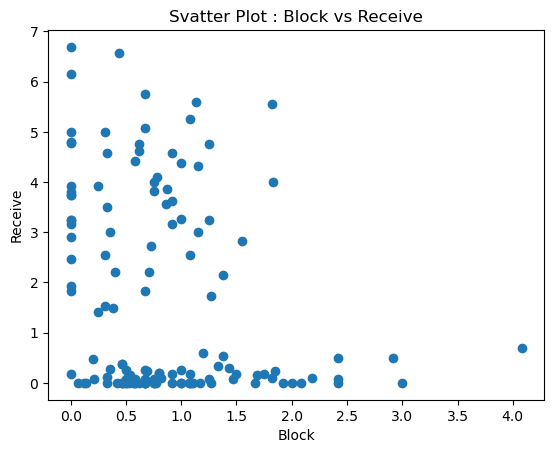

In [28]:
plt.scatter(df["Block"], df["Receive"])
plt.title("Svatter Plot : Block vs Receive")
plt.xlabel("Block")
plt.ylabel("Receive")
plt.show()

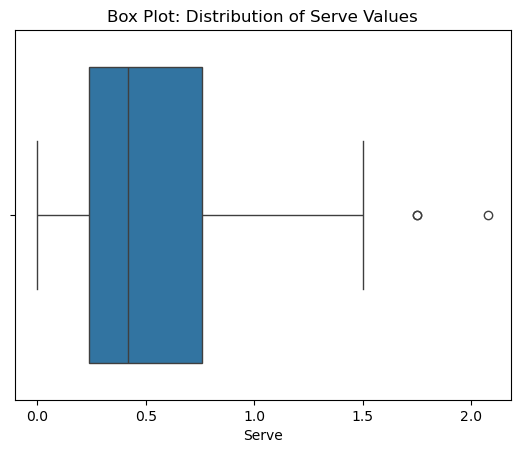

In [ ]:
# Doning a boxplot using the serve columes.

sns.boxplot(x = df["Serve"])
plt.title("Box Plot: Distribution of Serve Values")
plt.xlabel("Serve")
plt.show()

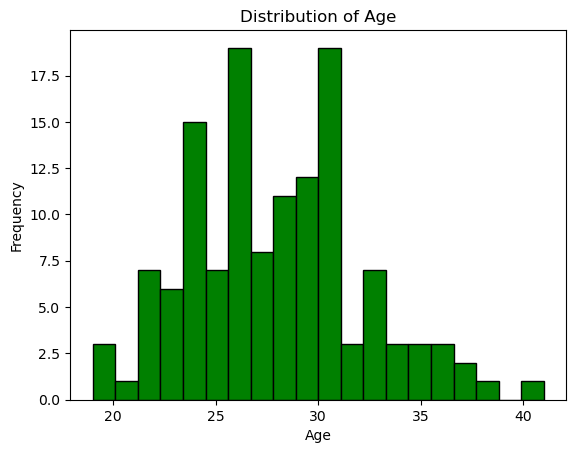

In [32]:
#
plt.hist(df["Age"], bins = 20, color= "green", edgecolor = "black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

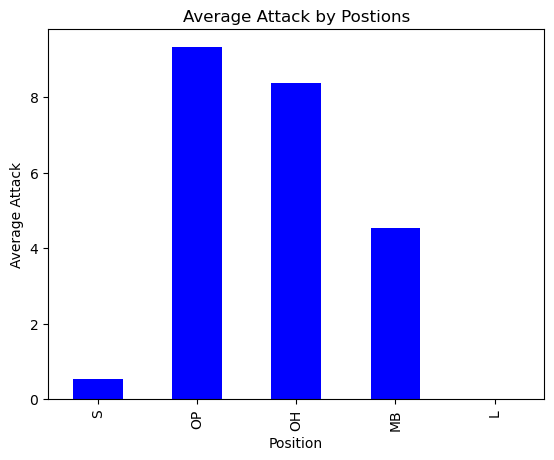

In [34]:
# 
avg_attack_by_postion = df.groupby("Position")["Attack"].mean()
avg_attack_by_postion.sort_index(ascending=False).plot(kind="bar", color="blue")
plt.title("Average Attack by Postions")
plt.xlabel("Position")
plt.ylabel("Average Attack")
plt.show()

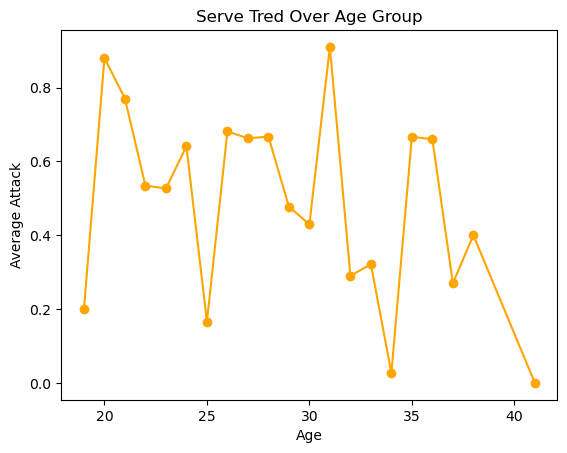

In [35]:
#

serve_tred_age = df.groupby("Age")["Serve"].mean()

serve_tred_age.plot(kind="line",marker = "o", linestyle = "-", color = "orange")
plt.title("Serve Tred Over Age Group")
plt.xlabel("Age")
plt.ylabel("Average Attack")
plt.show()